# Aplikativnost CMP

Cilj: Napisite celosten robotski program, ki iz zacetne lege najprej pobere rocko in jo premakne na koncno lego

1. Zajemite trajektorijo, ki pobere in odloži ročko.

2. Izvedite DMP togo (brez ročke) in narišite.

3. Izvedite DMP togo (z ročko) in narišite.

4. Zajemite navore brez ročke in izvedite CMP podajno in narišite.

5. Izvedite isti CMP z ročko ter narišite trajektorijo in napako.

6. Zajemite navore z ročko ter narišite trajektorijo in napako.

7. Spremenite gib s spremembo cilja trajektorije ter izvedite CMP.

8. Narišite trajektorijo in napako.

9. Primerjajte vse napake izvedbe in podajte zaključke glede CMP.

Skupaj z Andrejem in Mihom se dogovorite za samostojni seminar.

In [1]:
import rospy
import time
import numpy as np
from utils import pip
ns = "pingvin_1"
rospy.init_node(ns)
from robotblockset.ros.franka import panda_ros
r = panda_ros(ns=ns, control_strategy="JointImpedance", init_node=False)

Panda::Initialized


In [2]:
from robotblockset.ros.grippers_ros import PandaGripper
g = PandaGripper(namespace=ns,robot=r)
r.SetGripper(g)

Panda:Gripper:ROS:Created


In [21]:
r.ErrorRecovery()

Panda::Recovering from errors:
 ['joint_velocity_violation']
Panda::Attempting to change robot mode from 4


0

**1. Zajemite trajektorijo, ki pobere in odloži ročko.**

In [4]:
def record_robot_state(robot, frequency, duration):
    interval = 1.0 / frequency
    
    N=int(frequency*duration)
    tt = np.zeros((N,1))
    qt = np.zeros((N,r.nj))
    dqt = np.zeros((N,r.nj))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    
    last_update = time.monotonic()

    while time.monotonic() <= end_time+interval and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            
            # Get robot state
            state = robot.GetState()
            
            tt[i] = t-start_time
            qt[i] = r.q
            dqt[i] = r.qdot

            # Update the last recorded time
            last_update = t
            i += 1
        
    return tt, qt, dqt, i, N    

In [20]:
r.SetJointCompliant() 


:Joint compliance changed 
Stiff:[0. 0. 0. 0. 0. 0. 0.]
Damp:[0. 0. 0. 0. 0. 0. 0.]


In [11]:
g.Close()

1

In [10]:
g.Open()

1

In [6]:
time.sleep(6)
print ("start")
tt, qt, dqt, i, N = record_robot_state(r,100,6)
print ("stop")

start
stop


**2. Izvedite DMP togo (brez ročke) in narišite.**

In [8]:
import utils
from utils import SoftSetJointCompliance
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)

:Joint compliance changed 
Stiff:[1200. 1200. 1200. 1200.    0.    0.    0.]
Damp:[25 25 25 25 10 10 10]


In [22]:
r.JMove(qt[0],5)
napaka_brez_rocke=[]
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    napaka_brez_rocke.append(np.linalg.norm(q-q_d))
    time.sleep(tm[0])

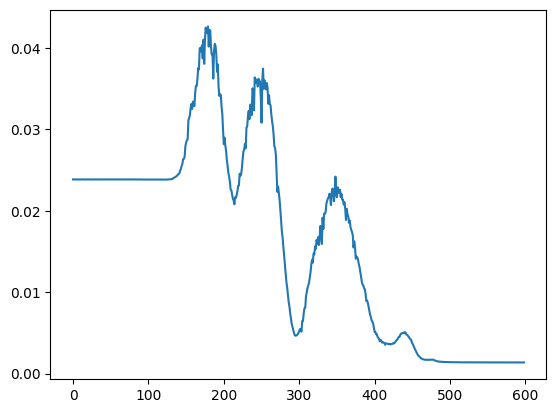

In [23]:
plt.plot(napaka_brez_rocke);

**3. Izvedite DMP togo (z ročko) in narišite.**


In [24]:
r.JMove(qt[0],5)
napaka_z_rocko=[]
time.sleep(3)
g.Close()
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    napaka_z_rocko.append(np.linalg.norm(q-q_d))
    time.sleep(tm[0])
g.Open()

1

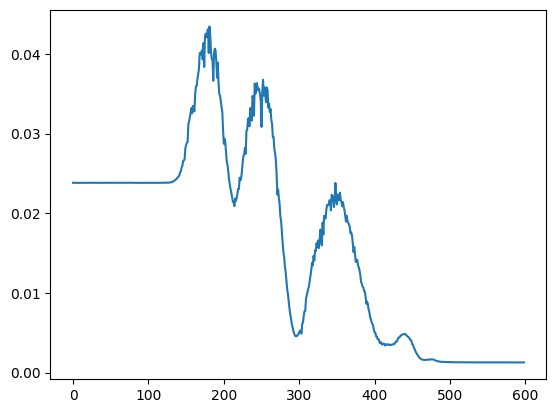

In [25]:
plt.plot(napaka_z_rocko);

**4. Zajemite navore brez ročke in izvedite CMP podajno in narišite.**


In [26]:
r.ResetCurrentTarget()
r.SetJointSoft(0.1)

:Joint compliance changed 
Stiff:[120. 120. 120. 120.  25.  25.  10.]
Damp:[2.5 2.5 2.5 2.5 1.  1.  1. ]


In [27]:
r.JMove(qt[0],5)
navori_brez_rocke=[]
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    navori_brez_rocke.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    time.sleep(tm[0])

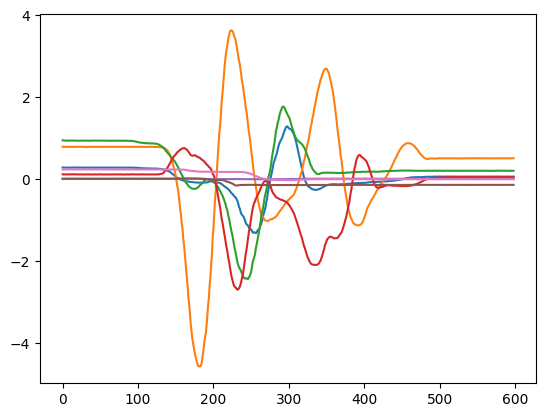

In [28]:
plt.plot(navori_brez_rocke);

**5. Izvedite isti CMP z ročko ter narišite trajektorijo in napako.**


In [31]:
r.JMove(qt[0],5)
napaka_z_rocko_CMP=[]
time.sleep(3)
g.Close()
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    napaka_z_rocko_CMP.append(np.linalg.norm(q-q_d))
    time.sleep(tm[0])
g.Open()

1

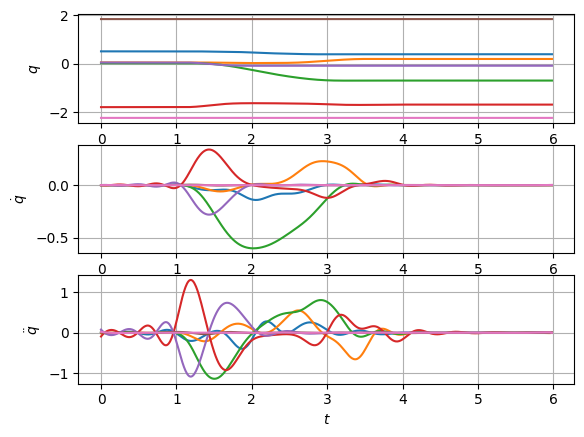

In [11]:
from dmp import DMP
from robotblockset.graphics import plotjtraj
import matplotlib.pyplot as plt
d = DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
trj_dec,t_dec=d.decode()
plotjtraj(qt=trj_dec, t=t_dec);


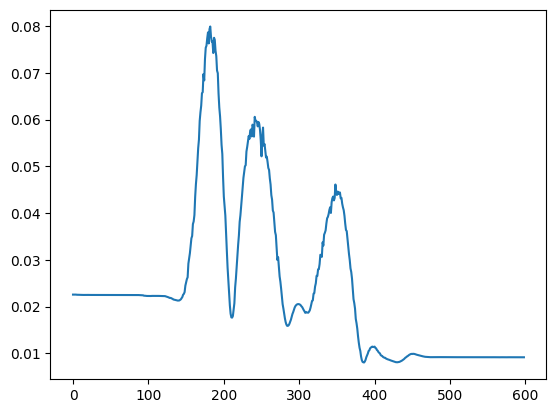

In [34]:
plt.plot(napaka_z_rocko_CMP);

**6. Zajemite navore z ročko ter narišite trajektorijo in napako.**

In [29]:
r.JMove(qt[0],5)
navori_z_rocko=[]
time.sleep(3)
g.Close()
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    navori_z_rocko.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    time.sleep(tm[0])
g.Open()

1

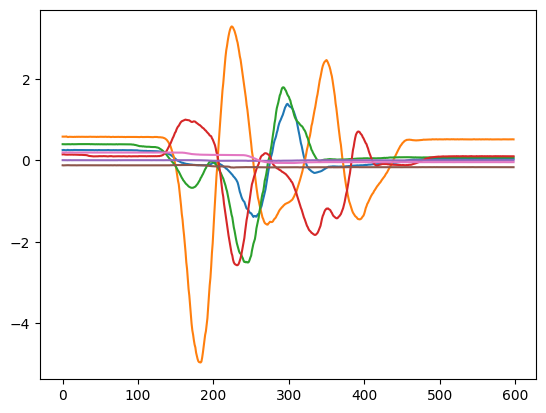

In [30]:
plt.plot(navori_z_rocko);

**7. Spremenite gib s spremembo cilja trajektorije ter izvedite CMP.**


In [7]:
# Zajem navorev v togem stanju
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)
r.SetJointSoft(1)

NameError: name 'SoftSetJointCompliance' is not defined

In [12]:
trj_dec,t_dec=d.decode()

In [13]:
navori_togi=[]
r.JMove(qt[0],5)
time.sleep(3)
g.Close()
N=np.size(qt,0)
for q, tm in zip(trj_dec, np.diff(t_dec, axis=0)): 
    navori_togi.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    time.sleep(1/100)
g.Open()

1

In [14]:
navori_togi_rocka=[]
r.JMove(qt[0],5)
time.sleep(3)
g.Close()
N=np.size(qt,0)
for q, tm in zip(trj_dec, np.diff(t_dec, axis=0)): 
    navori_togi_rocka.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    time.sleep(1/100)
g.Open()

1

In [15]:
navori_zunanji= np.array(navori_togi_rocka) - np.array(navori_togi)

In [16]:
from robotblockset.RBF import encodeRBF
RBF= encodeRBF(t_dec[:-1], navori_zunanji)

In [90]:
t_dec[-1]

5.980039228404205

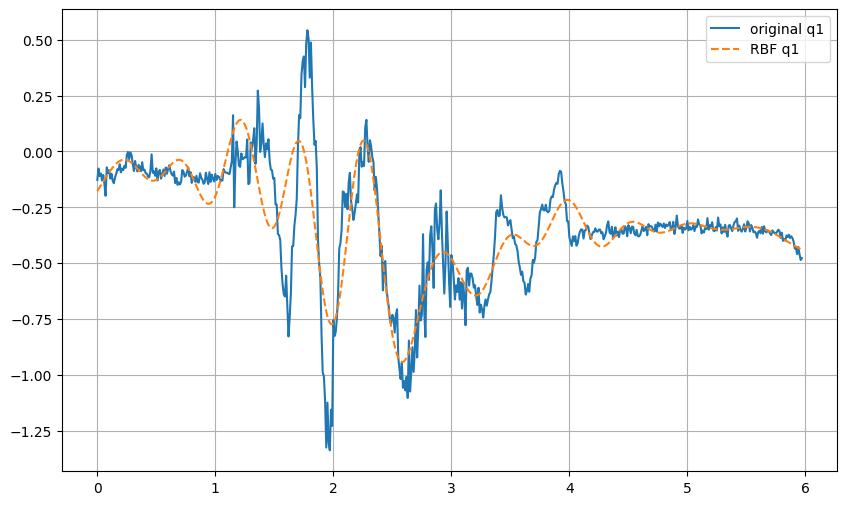

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from robotblockset.RBF import decodeRBF

tau_rbf = decodeRBF(t_dec[:-1], RBF)

plt.figure(figsize=(10,6))
plt.plot(t_dec[:-1], navori_zunanji[:,0], label='original q1')
plt.plot(t_dec[:-1], tau_rbf[:,0], '--', label='RBF q1')
plt.legend()
plt.grid()
plt.show()

In [ ]:
**8. Narišite trajektorijo in napako.**

array([ 0.44804473,  0.45137996, -0.25692549, -2.32287528, -0.11865892,
        2.81534676, -1.99402352])

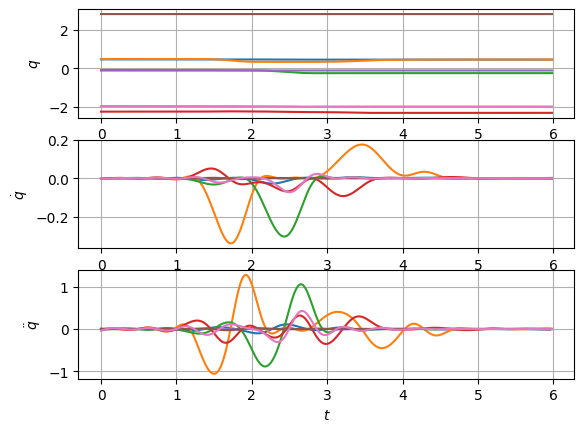

In [68]:
d = DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
trj_dec,t_dec=d.decode()
plotjtraj(qt=trj_dec, t=t_dec);
d.goal

array([ 0.54804473,  0.45137996, -0.25692549, -2.32287528, -0.11865892,
        2.81534676, -1.99402352])

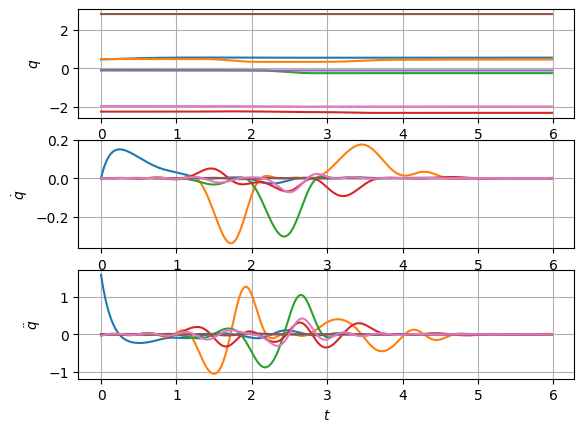

In [67]:
d = DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
d.goal[0]+=0.1
trj_dec_goal,t_dec_goal=d.decode()
plotjtraj(qt=trj_dec_goal, t=t_dec_goal);
d.goal

**9. Primerjajte vse napake izvedbe in podajte zaključke glede CMP.**

In [ ]:
CMP ima manjše ojačanje napake, sledi manj agresivno.